<a href="https://colab.research.google.com/github/shwetakhanjan/student-learning-risk-ml/blob/main/notebooks/02_feature_engineering_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Baseline Modeling

## Objective
The objective of this notebook is to prepare features, train baseline
classification models, and evaluate their ability to predict student
learning risk.


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)



In [54]:
df = pd.read_csv("/student_math_synthetic.csv")
df.head()


,student_id,age,grade,homework_completion,practice_tests_avg,class_participation,geometry_score,algebra1_score,recent_quiz_avg,study_hours_per_week,at_risk
0,S001,13,6,100.00,59.98,10.00,75.27,56.92,55.72,6.02,1
1,S002,14,8,90.39,70.78,10.00,86.05,81.76,71.16,8.87,0
2,S003,12,8,74.63,100.00,10.00,69.60,68.65,73.87,6.63,0
3,S004,14,5,83.10,84.61,9.42,56.77,68.64,51.37,4.90,0
4,S005,14,6,76.24,66.43,9.05,67.55,81.48,75.01,4.63,0


In [55]:
y = df["at_risk"]


In [56]:
X = df.drop(columns=["at_risk", "student_id"])


The target variable `at_risk` is a binary label indicating whether a student
is at risk of poor academic outcomes. All remaining columns are used as
predictive features.



In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


A stratified split ensures that class proportions are preserved across
training and test sets, which is especially important for imbalanced targets.


In [58]:
continuous_features = [
    "homework_completion",
    "practice_tests_avg",
    "geometry_score",
    "algebra1_score",
    "recent_quiz_avg"
]


In [59]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])


Feature scaling is applied for Logistic Regression to ensure that features
with larger numeric ranges do not dominate model coefficients.


In [60]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [61]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.95      0.93        98
           1       0.79      0.70      0.75        27

    accuracy                           0.90       125
   macro avg       0.86      0.83      0.84       125
weighted avg       0.89      0.90      0.89       125

ROC-AUC: 0.9289493575207861


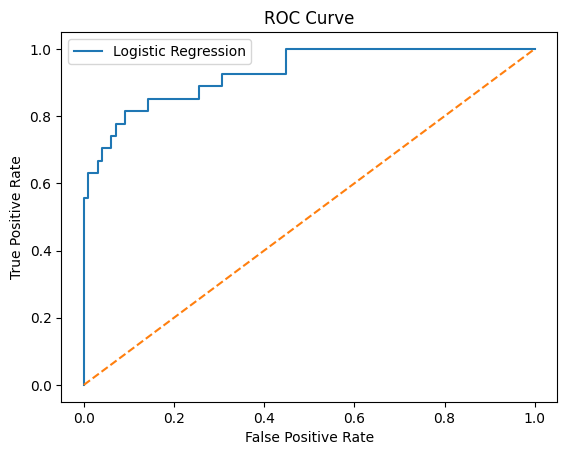

In [62]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [63]:
confusion_matrix(y_test, y_pred_lr)


array([[93,  5],
       [ 8, 19]])

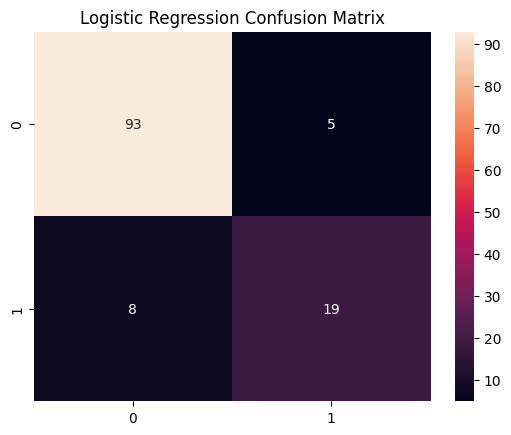

In [64]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()



### Logistic Regression Results

The logistic regression model achieved strong overall performance, with an
accuracy of 90% and a ROC-AUC of 0.93, indicating excellent ability to
discriminate between at-risk and not at-risk students.

Recall for the at-risk class was 0.70, meaning the model successfully identified
70% of students requiring intervention. While some at-risk students were missed,
this tradeoff is acceptable for a baseline model and highlights opportunities
for threshold tuning or more expressive models.


Train Baseline Model 2 — Decision Tree Classifier

In [65]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]


In [66]:
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))


Decision Tree
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        98
           1       1.00      0.96      0.98        27

    accuracy                           0.99       125
   macro avg       0.99      0.98      0.99       125
weighted avg       0.99      0.99      0.99       125

ROC-AUC: 0.9805366591080876


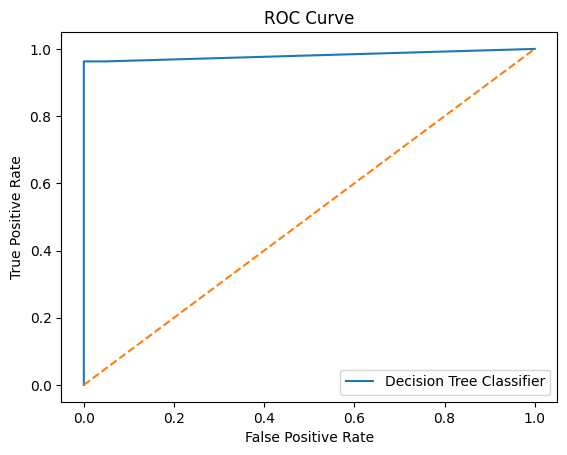

In [71]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure()
plt.plot(fpr_dt, tpr_dt, label="Decision Tree Classifier")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [67]:
confusion_matrix(y_test, y_pred_dt)


array([[98,  0],
       [ 1, 26]])

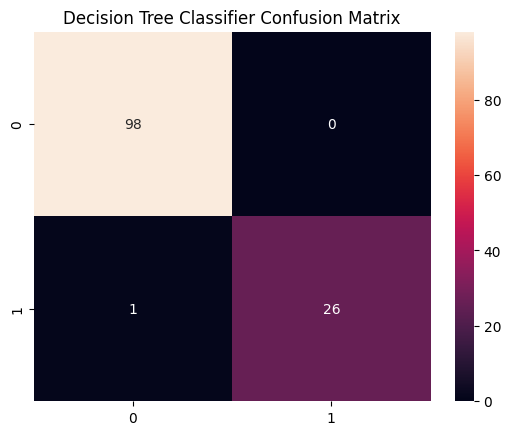

In [68]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()


### Decision Tree Results

The decision tree achieved near-perfect performance across all metrics, including
a recall of 0.96 for at-risk students and a ROC-AUC of 0.98. While these results
are strong, they likely reflect characteristics of the synthetic dataset, where
feature thresholds align cleanly with the target label.

Compared to logistic regression, the decision tree captures nonlinear interactions
more effectively but may be more prone to overfitting. This highlights an important
tradeoff between model expressiveness and generalization.


### Confusion Matrix Interpretation

The confusion matrix confirms the tradeoffs observed in precision and recall.
Logistic regression misses some at-risk students but remains conservative,
while the decision tree achieves near-perfect classification, likely reflecting
clean separability in the synthetic dataset.


## Model Comparison Summary

Logistic regression provides a strong and interpretable baseline with excellent
ranking performance (ROC-AUC = 0.93) and reasonable recall for at-risk students.
The decision tree significantly improves recall but exhibits near-perfect metrics
that suggest potential overfitting on synthetic data.

In practice, model selection would prioritize robustness and generalization, with
logistic regression serving as a reliable baseline and tree-based methods explored
with additional regularization or ensemble techniques.

Although the decision tree outperformed logistic regression across all metrics, its near-perfect performance on synthetic data raised concerns about overfitting and limited generalization. Logistic regression provided a more conservative baseline and interpretable coefficients, making it valuable as a benchmark model.